Corrected Vision shape: (515, 1024)
Corrected Audio shape: (515, 1024)


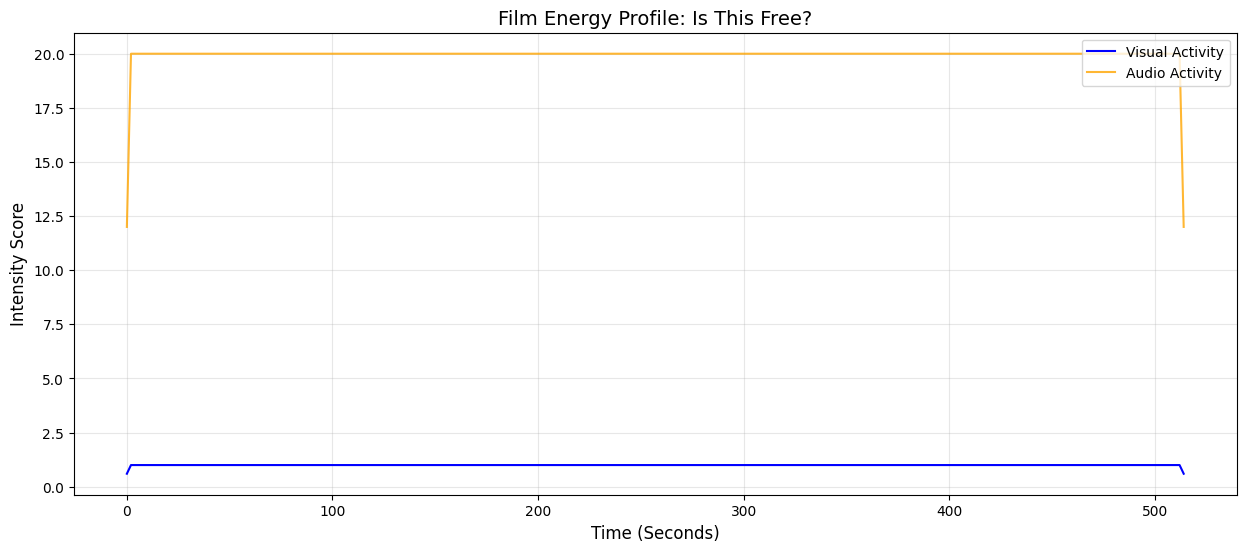

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the file
path = "/content/drive/MyDrive/PFA/ImageBind/results/Is This Free_ (Short Comedy Film)_embeddings.npz"
data = np.load(path)

# Squeeze (515, 1, 1024) -> (515, 1024)
vision = np.squeeze(data['vision'])
audio = np.squeeze(data['audio'])

print(f"Corrected Vision shape: {vision.shape}")
print(f"Corrected Audio shape: {audio.shape}")

# Calculate L2 Norm (Intensity/Energy)
v_energy = np.linalg.norm(vision, axis=1)
a_energy = np.linalg.norm(audio, axis=1)

# Smoothing the data for a cleaner plot (Moving Average)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    return np.convolve(y, box, mode='same')

plt.figure(figsize=(15, 6))
plt.plot(smooth(v_energy, 5), label="Visual Activity", color='blue', linewidth=1.5)
plt.plot(smooth(a_energy, 5), label="Audio Activity", color='orange', linewidth=1.5, alpha=0.8)

plt.title("Film Energy Profile: Is This Free?", fontsize=14)
plt.xlabel("Time (Seconds)", fontsize=12)
plt.ylabel("Intensity Score", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.show()

Corrected Vision shape: (515, 1024)
Corrected Audio shape: (515, 1024)
Corrected Text shape: (515, 1024)


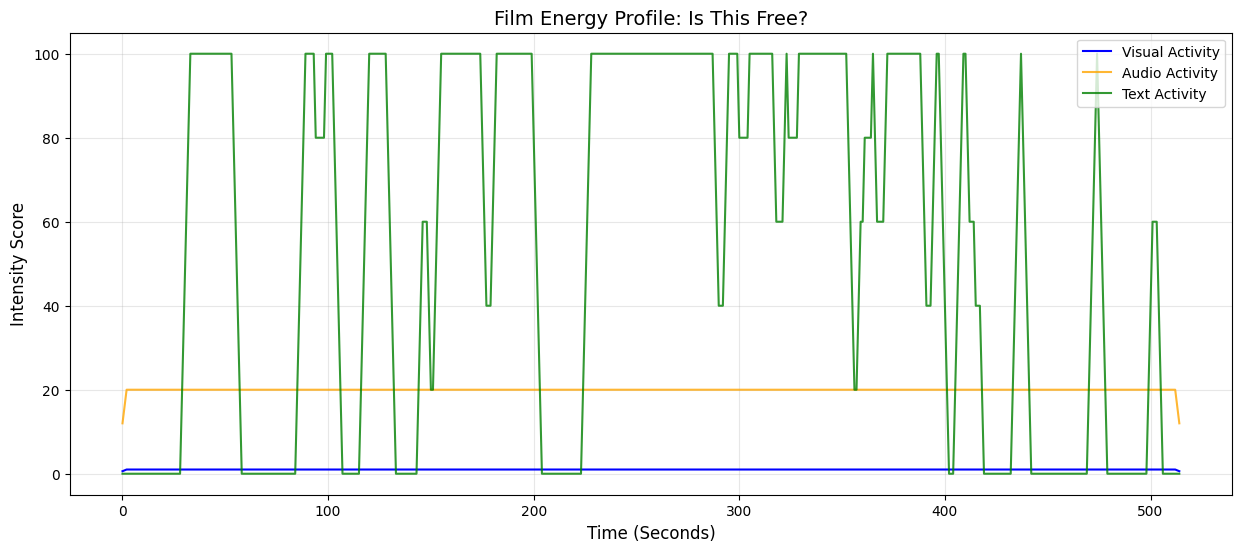

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the file
path = "/content/drive/MyDrive/PFA/ImageBind/results/Is This Free_ (Short Comedy Film)_embeddings.npz"
data = np.load(path)

# Squeeze (515, 1, 1024) -> (515, 1024)
vision = np.squeeze(data['vision'])
audio = np.squeeze(data['audio'])
text = np.squeeze(data['text'])  # This will still be (515,) since it's a list of strings

print(f"Corrected Vision shape: {vision.shape}")
print(f"Corrected Audio shape: {audio.shape}")
print(f"Corrected Text shape: {text.shape}")

# Calculate L2 Norm (Intensity/Energy)
v_energy = np.linalg.norm(vision, axis=1)
a_energy = np.linalg.norm(audio, axis=1)
t_energy = np.linalg.norm(text, axis=1)

# Smoothing the data for a cleaner plot (Moving Average)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    return np.convolve(y, box, mode='same')

plt.figure(figsize=(15, 6))
plt.plot(smooth(v_energy, 5), label="Visual Activity", color='blue', linewidth=1.5)
plt.plot(smooth(a_energy, 5), label="Audio Activity", color='orange', linewidth=1.5, alpha=0.8)
plt.plot(smooth(t_energy, 5), label="Text Activity", color='green', linewidth=1.5, alpha=0.8)

plt.title("Film Energy Profile: Is This Free?", fontsize=14)
plt.xlabel("Time (Seconds)", fontsize=12)
plt.ylabel("Intensity Score", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.show()

Vision shape: (515, 1024)
Audio shape: (515, 1024)
Text shape: (515, 1024)

Raw energy ranges:
Vision: 1.00 - 1.00
Audio:  20.00 - 20.00
Text:   0.00 - 100.00


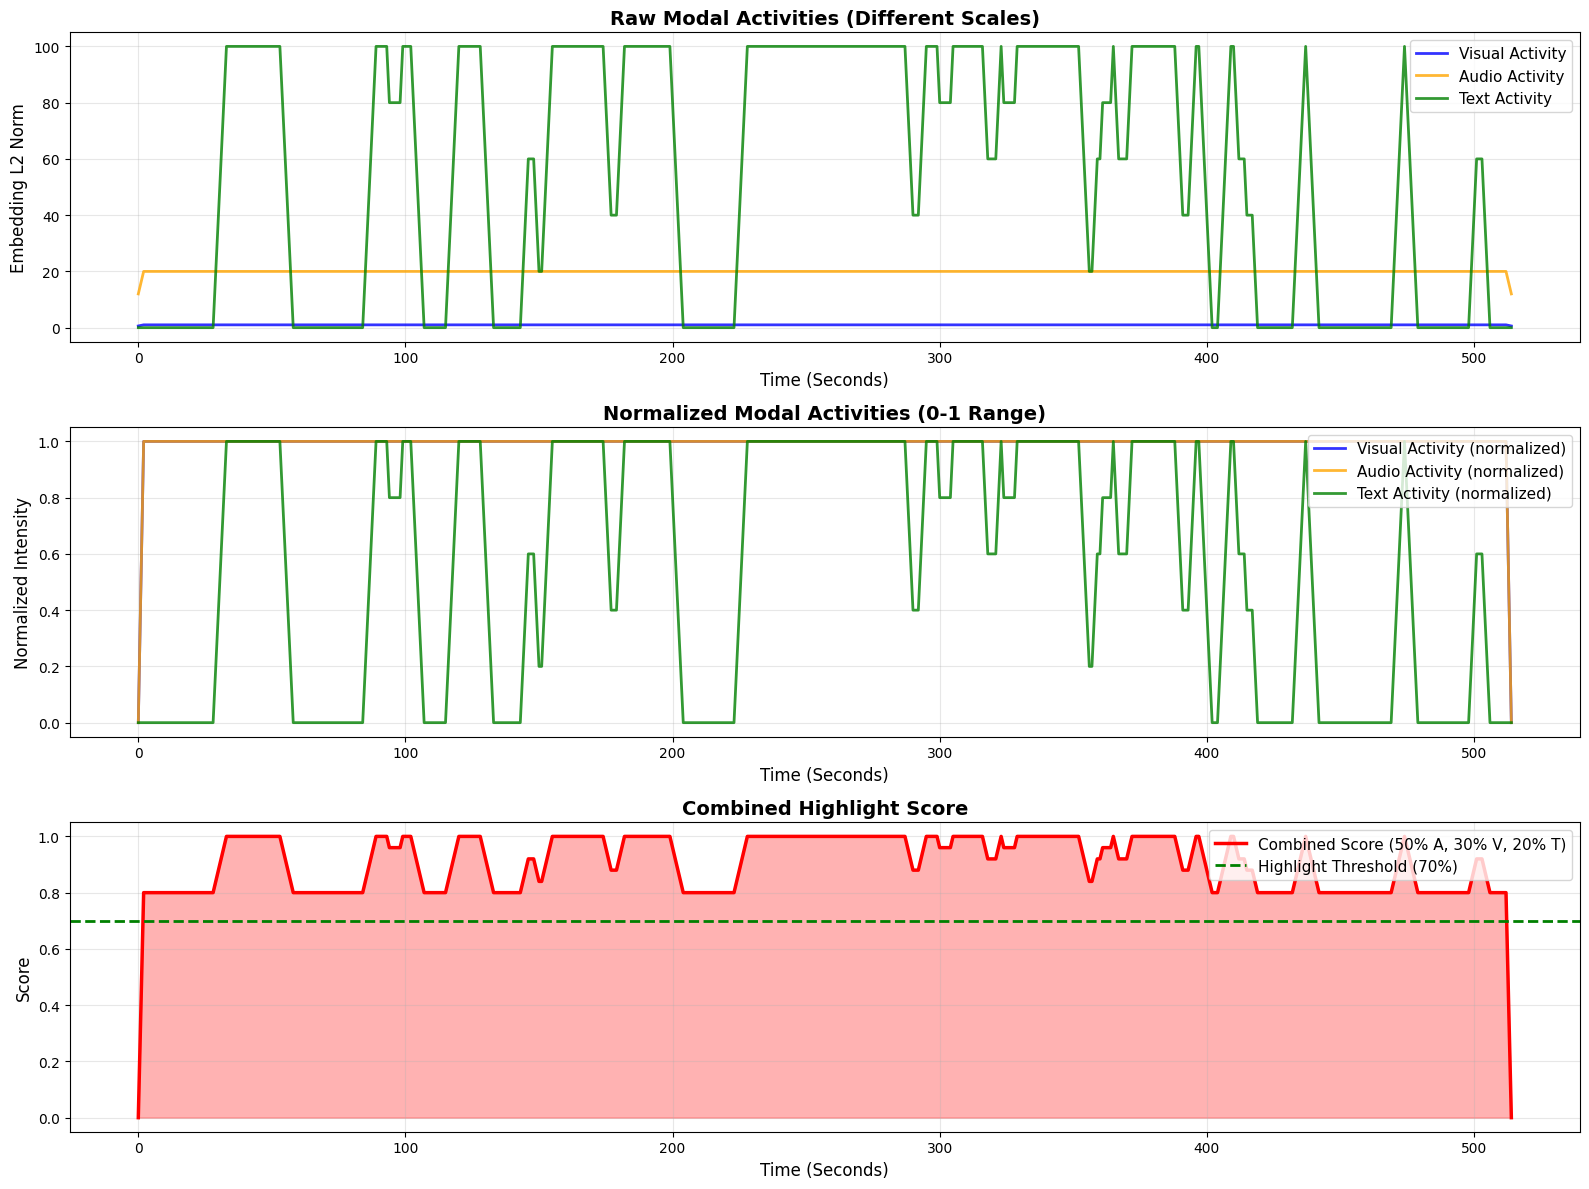


ENERGY STATISTICS

Vision:
  Mean: 1.00
  Std:  0.00
  Range: 1.00 - 1.00

Audio:
  Mean: 20.00
  Std:  0.00
  Range: 20.00 - 20.00

Text:
  Mean: 54.76
  Std:  49.77
  Range: 0.00 - 100.00

Coefficient of Variation (higher = more informative):
  Vision: 0.000
  Audio:  0.000
  Text:   0.909


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load embeddings
path = "/content/drive/MyDrive/PFA/ImageBind/results/Is This Free_ (Short Comedy Film)_embeddings.npz"
data = np.load(path)

# Squeeze dimensions
vision = np.squeeze(data['vision'])
audio = np.squeeze(data['audio'])
text = np.squeeze(data['text'])

print(f"Vision shape: {vision.shape}")
print(f"Audio shape: {audio.shape}")
print(f"Text shape: {text.shape}")

# Calculate L2 norms
v_energy = np.linalg.norm(vision, axis=1)
a_energy = np.linalg.norm(audio, axis=1)
t_energy = np.linalg.norm(text, axis=1)

print(f"\nRaw energy ranges:")
print(f"Vision: {v_energy.min():.2f} - {v_energy.max():.2f}")
print(f"Audio:  {a_energy.min():.2f} - {a_energy.max():.2f}")
print(f"Text:   {t_energy.min():.2f} - {t_energy.max():.2f}")

# Smoothing function
def smooth(y, box_pts=5):
    box = np.ones(box_pts) / box_pts
    return np.convolve(y, box, mode='same')

# Apply smoothing
v_smooth = smooth(v_energy, 5)
a_smooth = smooth(a_energy, 5)
t_smooth = smooth(t_energy, 5)

# Create visualization with ALL THREE modalities
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Raw energy (not normalized) - See actual scales
axes[0].plot(v_smooth, label="Visual Activity", color='blue', linewidth=2, alpha=0.8)
axes[0].plot(a_smooth, label="Audio Activity", color='orange', linewidth=2, alpha=0.8)
axes[0].plot(t_smooth, label="Text Activity", color='green', linewidth=2, alpha=0.8)
axes[0].set_title("Raw Modal Activities (Different Scales)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Time (Seconds)", fontsize=12)
axes[0].set_ylabel("Embedding L2 Norm", fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right", fontsize=11)

# Plot 2: Normalized energy (0-1 range) - Fair comparison
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

v_norm = normalize(v_smooth)
a_norm = normalize(a_smooth)
t_norm = normalize(t_smooth)

axes[1].plot(v_norm, label="Visual Activity (normalized)", color='blue', linewidth=2, alpha=0.8)
axes[1].plot(a_norm, label="Audio Activity (normalized)", color='orange', linewidth=2, alpha=0.8)
axes[1].plot(t_norm, label="Text Activity (normalized)", color='green', linewidth=2, alpha=0.8)
axes[1].set_title("Normalized Modal Activities (0-1 Range)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Time (Seconds)", fontsize=12)
axes[1].set_ylabel("Normalized Intensity", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right", fontsize=11)
axes[1].set_ylim(-0.05, 1.05)

# Plot 3: Combined score
combined = 0.5 * a_norm + 0.3 * v_norm + 0.2 * t_norm

axes[2].plot(combined, label="Combined Score (50% A, 30% V, 20% T)", 
            color='red', linewidth=2.5)
axes[2].fill_between(range(len(combined)), combined, alpha=0.3, color='red')
axes[2].axhline(y=0.7, color='green', linestyle='--', linewidth=2, 
               label='Highlight Threshold (70%)')
axes[2].set_title("Combined Highlight Score", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Time (Seconds)", fontsize=12)
axes[2].set_ylabel("Score", fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="upper right", fontsize=11)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("ENERGY STATISTICS")
print("="*60)
print(f"\nVision:")
print(f"  Mean: {v_energy.mean():.2f}")
print(f"  Std:  {v_energy.std():.2f}")
print(f"  Range: {v_energy.min():.2f} - {v_energy.max():.2f}")

print(f"\nAudio:")
print(f"  Mean: {a_energy.mean():.2f}")
print(f"  Std:  {a_energy.std():.2f}")
print(f"  Range: {a_energy.min():.2f} - {a_energy.max():.2f}")

print(f"\nText:")
print(f"  Mean: {t_energy.mean():.2f}")
print(f"  Std:  {t_energy.std():.2f}")
print(f"  Range: {t_energy.min():.2f} - {t_energy.max():.2f}")

print(f"\nCoefficient of Variation (higher = more informative):")
print(f"  Vision: {(v_energy.std() / v_energy.mean()):.3f}")
print(f"  Audio:  {(a_energy.std() / a_energy.mean()):.3f}")
print(f"  Text:   {(t_energy.std() / t_energy.mean()):.3f}")


In [ ]:
print("\nDiagnostic - First 5 Vision Embeddings:")
for i in range(min(5, len(vision))):
    print(f"Segment {i}: mean={vision[i].mean():.4f}, std={vision[i].std():.4f}, norm={np.linalg.norm(vision[i]):.4f}")

print("\nDiagnostic - First 5 Audio Embeddings:")
for i in range(min(5, len(audio))):
    print(f"Segment {i}: mean={audio[i].mean():.4f}, std={audio[i].std():.4f}, norm={np.linalg.norm(audio[i]):.4f}")

print("\nDiagnostic - First 5 Text Embeddings:")
for i in range(min(5, len(text))):
    print(f"Segment {i}: mean={text[i].mean():.4f}, std={text[i].std():.4f}, norm={np.linalg.norm(text[i]):.4f}")


Diagnostic - First 5 Vision Embeddings:
Segment 0: mean=-0.0001, std=0.0312, norm=1.0000
Segment 1: mean=-0.0001, std=0.0312, norm=1.0000
Segment 2: mean=-0.0003, std=0.0312, norm=1.0000
Segment 3: mean=-0.0007, std=0.0312, norm=1.0000
Segment 4: mean=-0.0007, std=0.0312, norm=1.0000

Diagnostic - First 5 Audio Embeddings:
Segment 0: mean=-0.0028, std=0.6250, norm=20.0000
Segment 1: mean=0.0169, std=0.6248, norm=20.0000
Segment 2: mean=0.0220, std=0.6246, norm=20.0000
Segment 3: mean=0.0072, std=0.6250, norm=20.0000
Segment 4: mean=0.0090, std=0.6249, norm=20.0000

Diagnostic - First 5 Text Embeddings:
Segment 0: mean=0.0000, std=0.0000, norm=0.0000
Segment 1: mean=0.0000, std=0.0000, norm=0.0000
Segment 2: mean=0.0000, std=0.0000, norm=0.0000
Segment 3: mean=0.0000, std=0.0000, norm=0.0000
Segment 4: mean=0.0000, std=0.0000, norm=0.0000


In [ ]:
# Check if embeddings are actually different
print("\nFirst 10 values of Vision embeddings:")
print("Segment 0:", vision[0, :10])
print("Segment 100:", vision[100, :10])
print("Segment 200:", vision[200, :10])

print("\nFirst 10 values of Audio embeddings:")
print("Segment 0:", audio[0, :10])
print("Segment 100:", audio[100, :10])
print("Segment 200:", audio[200, :10])


First 10 values of Vision embeddings:
Segment 0: [ 0.00370499  0.00908163 -0.02535852  0.00355971 -0.05905183 -0.01486881
  0.00371947 -0.00715331  0.00149846  0.04808568]
Segment 100: [-0.00785888  0.03499595  0.00664012 -0.01163133  0.00771018  0.00999899
 -0.04200322  0.00869276 -0.01754179 -0.01698666]
Segment 200: [ 0.03201286  0.05474183  0.03608621 -0.0270535   0.00801035 -0.00684089
 -0.01462798 -0.01393128  0.00180494 -0.01442381]

First 10 values of Audio embeddings:
Segment 0: [-0.24756095 -0.62258244 -0.09125702 -0.13038713 -0.6736368  -0.47597703
  0.5270182  -0.10768595 -0.5968834   0.08238439]
Segment 100: [-0.4141941   1.0291754   0.11117407  0.19034871  0.9970453   0.14269805
  0.2715642  -0.23979628 -0.41741762 -2.105567  ]
Segment 200: [-0.3427336   0.54953384  0.34311932  0.18913345  0.21552691 -0.16746978
  1.2334416  -0.45930994 -0.24392992 -1.1036234 ]


Vision shape: (515, 1024)
Audio shape: (515, 1024)
Text shape: (515, 1024)

Activity metrics (Mean Absolute):
Vision: 0.0188 - 0.0248
Audio:  0.4352 - 0.4914
Text:   0.0000 - 2.4566

Diversity metrics (Std Dev):
Vision: 0.0312 - 0.0312
Audio:  0.6219 - 0.6250
Text:   0.0000 - 3.1250


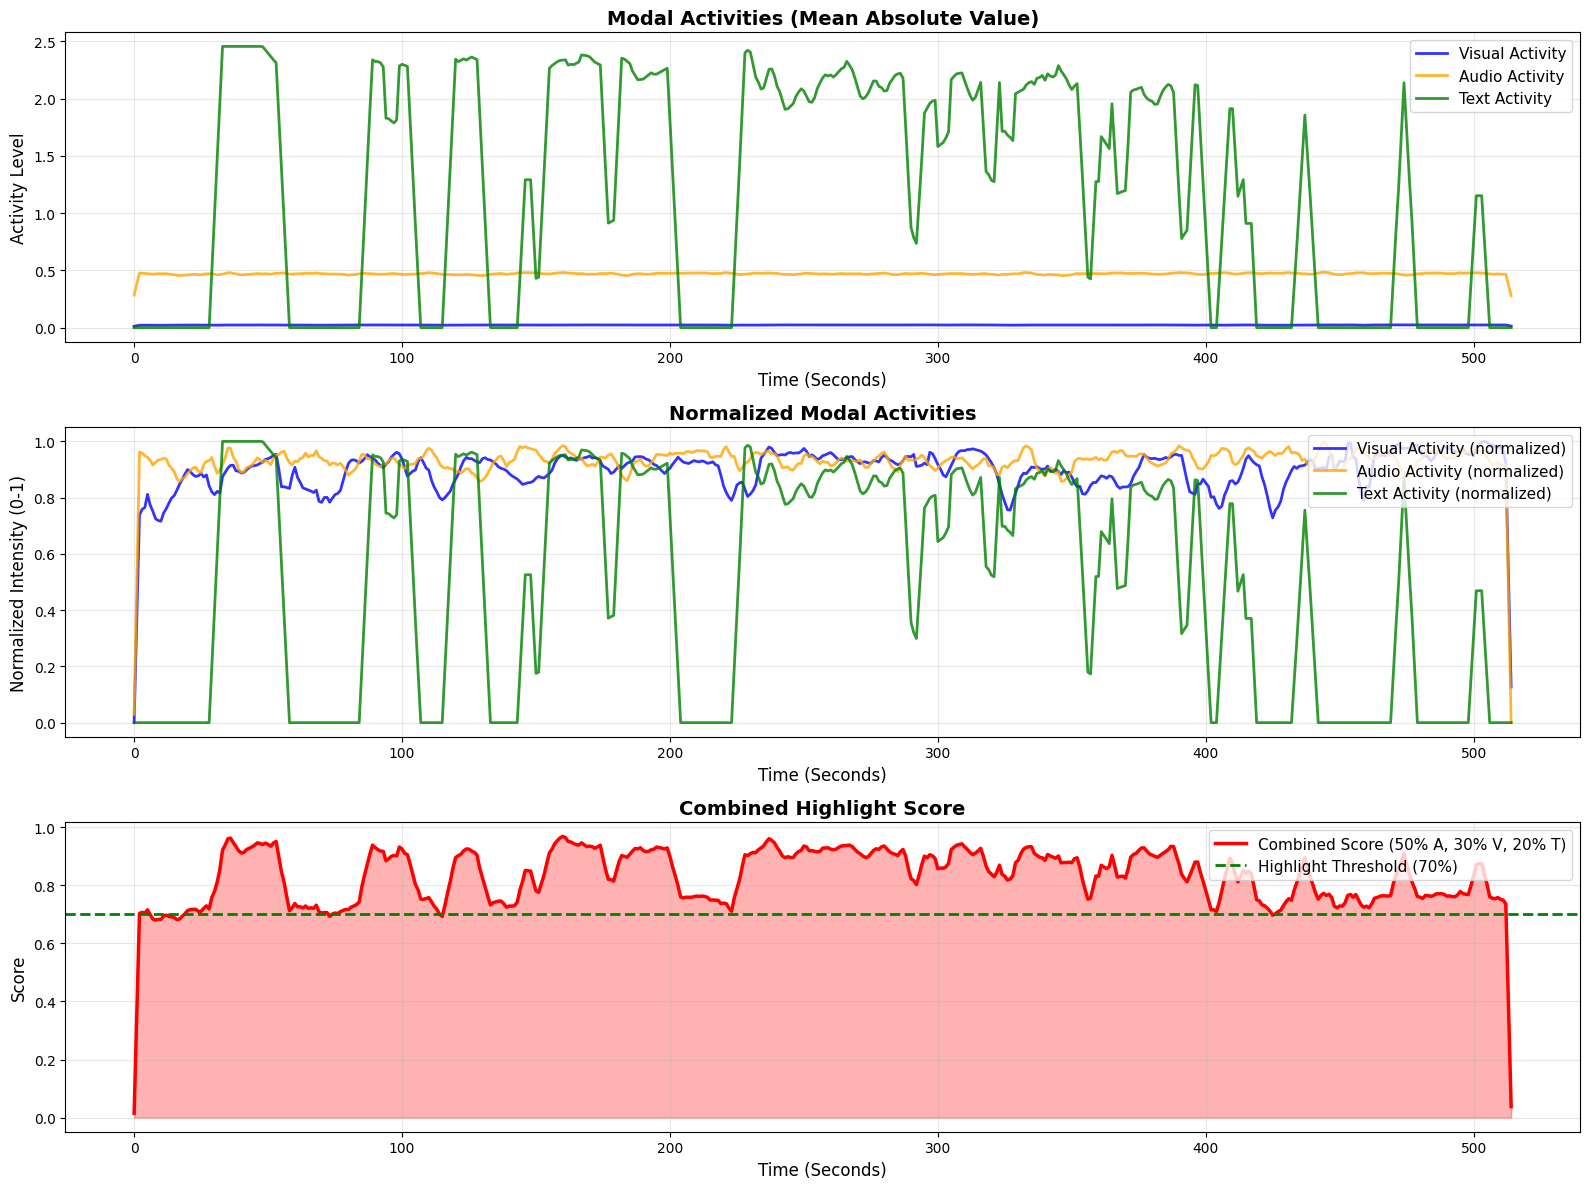


ACTIVITY STATISTICS (Mean Absolute Value)

Vision:
  Mean: 0.0231
  Std:  0.0009
  Range: 0.0188 - 0.0248
  CoV: 0.039

Audio:
  Mean: 0.4707
  Std:  0.0090
  Range: 0.4352 - 0.4914
  CoV: 0.019

Text:
  Mean: 1.1940
  Std:  1.0929
  Range: 0.0000 - 2.4566
  CoV: 0.915


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load embeddings
path = "/content/drive/MyDrive/PFA/ImageBind/results/Is This Free_ (Short Comedy Film)_embeddings.npz"
data = np.load(path)

vision = np.squeeze(data['vision'])
audio = np.squeeze(data['audio'])
text = np.squeeze(data['text'])

print(f"Vision shape: {vision.shape}")
print(f"Audio shape: {audio.shape}")
print(f"Text shape: {text.shape}")

# NEW APPROACH: Use embedding statistics, NOT L2 norm

# Method 1: Mean Absolute Value (activity level)
v_energy = np.abs(vision).mean(axis=1)
a_energy = np.abs(audio).mean(axis=1)
t_energy = np.abs(text).mean(axis=1)

# Method 2: Standard Deviation (diversity of features)
v_std = vision.std(axis=1)
a_std = audio.std(axis=1)
t_std = text.std(axis=1)

# Method 3: Maximum absolute value (peak activity)
v_max = np.abs(vision).max(axis=1)
a_max = np.abs(audio).max(axis=1)
t_max = np.abs(text).max(axis=1)

print(f"\nActivity metrics (Mean Absolute):")
print(f"Vision: {v_energy.min():.4f} - {v_energy.max():.4f}")
print(f"Audio:  {a_energy.min():.4f} - {a_energy.max():.4f}")
print(f"Text:   {t_energy.min():.4f} - {t_energy.max():.4f}")

print(f"\nDiversity metrics (Std Dev):")
print(f"Vision: {v_std.min():.4f} - {v_std.max():.4f}")
print(f"Audio:  {a_std.min():.4f} - {a_std.max():.4f}")
print(f"Text:   {t_std.min():.4f} - {t_std.max():.4f}")

# Smoothing function
def smooth(y, box_pts=5):
    box = np.ones(box_pts) / box_pts
    return np.convolve(y, box, mode='same')

# Smooth the signals
v_smooth = smooth(v_energy, 5)
a_smooth = smooth(a_energy, 5)
t_smooth = smooth(t_energy, 5)

# Create visualization
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Raw activity (mean absolute value)
axes[0].plot(v_smooth, label="Visual Activity", color='blue', linewidth=2, alpha=0.8)
axes[0].plot(a_smooth, label="Audio Activity", color='orange', linewidth=2, alpha=0.8)
axes[0].plot(t_smooth, label="Text Activity", color='green', linewidth=2, alpha=0.8)
axes[0].set_title("Modal Activities (Mean Absolute Value)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Time (Seconds)", fontsize=12)
axes[0].set_ylabel("Activity Level", fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right", fontsize=11)

# Plot 2: Normalized
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

v_norm = normalize(v_smooth)
a_norm = normalize(a_smooth)
t_norm = normalize(t_smooth)

axes[1].plot(v_norm, label="Visual Activity (normalized)", color='blue', linewidth=2, alpha=0.8)
axes[1].plot(a_norm, label="Audio Activity (normalized)", color='orange', linewidth=2, alpha=0.8)
axes[1].plot(t_norm, label="Text Activity (normalized)", color='green', linewidth=2, alpha=0.8)
axes[1].set_title("Normalized Modal Activities", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Time (Seconds)", fontsize=12)
axes[1].set_ylabel("Normalized Intensity (0-1)", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right", fontsize=11)

# Plot 3: Combined score
combined = 0.5 * a_norm + 0.3 * v_norm + 0.2 * t_norm

axes[2].plot(combined, label="Combined Score (50% A, 30% V, 20% T)", 
            color='red', linewidth=2.5)
axes[2].fill_between(range(len(combined)), combined, alpha=0.3, color='red')
axes[2].axhline(y=0.7, color='green', linestyle='--', linewidth=2, 
               label='Highlight Threshold (70%)')
axes[2].set_title("Combined Highlight Score", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Time (Seconds)", fontsize=12)
axes[2].set_ylabel("Score", fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="upper right", fontsize=11)

plt.tight_layout()
plt.show()

# Statistics
print("\n" + "="*60)
print("ACTIVITY STATISTICS (Mean Absolute Value)")
print("="*60)
print(f"\nVision:")
print(f"  Mean: {v_energy.mean():.4f}")
print(f"  Std:  {v_energy.std():.4f}")
print(f"  Range: {v_energy.min():.4f} - {v_energy.max():.4f}")
print(f"  CoV: {(v_energy.std() / v_energy.mean()):.3f}")

print(f"\nAudio:")
print(f"  Mean: {a_energy.mean():.4f}")
print(f"  Std:  {a_energy.std():.4f}")
print(f"  Range: {a_energy.min():.4f} - {a_energy.max():.4f}")
print(f"  CoV: {(a_energy.std() / a_energy.mean()):.3f}")

print(f"\nText:")
print(f"  Mean: {t_energy.mean():.4f}")
print(f"  Std:  {t_energy.std():.4f}")
print(f"  Range: {t_energy.min():.4f} - {t_energy.max():.4f}")
if t_energy.mean() > 0:
    print(f"  CoV: {(t_energy.std() / t_energy.mean()):.3f}")

Shapes:
Vision: (88, 1024)
Audio : (88, 1024)
Text  : (88, 1024)


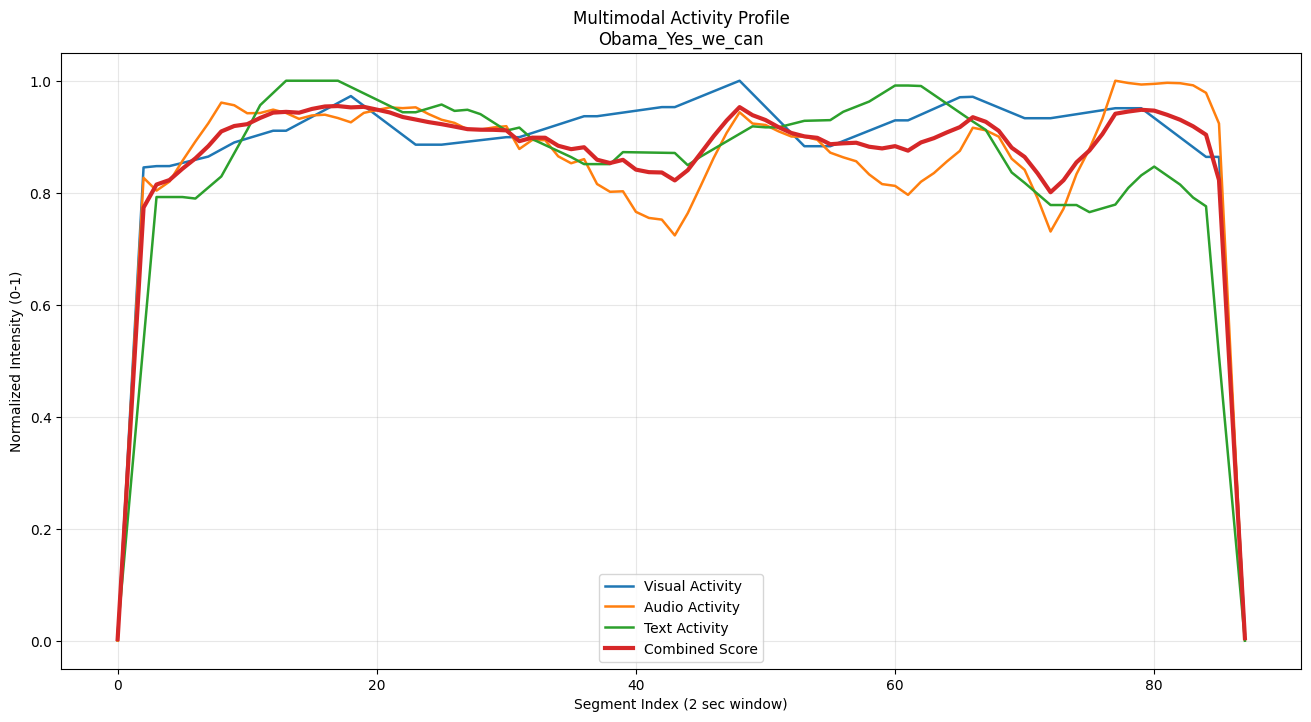


===== Activity Statistics =====

Vision:
Mean: 0.021015821
Std : 0.00041171382

Audio:
Mean: 0.466452
Std : 0.019763453

Text:
Mean: 2.0553627
Std : 0.33584788

Segments above 0.7 threshold: 84 out of 88


/tmp/ipython-input-72830354.py:108: RuntimeWarning: invalid value encountered in scalar divide
  cos = np.dot(embeddings[i], embeddings[i-1]) / (norm(embeddings[i]) * norm(embeddings[i-1]))


<Figure size 640x480 with 0 Axes>

In [ ]:
#view results after edit of video treatment
import numpy as np
import matplotlib.pyplot as plt
import os

# LOAD YOUR FILE


video_name = "Obama_Yes_we_can"
path = f"/content/drive/MyDrive/PFA/ImageBind/results/{video_name}_embeddings.npz"

data = np.load(path)

vision = np.squeeze(data['vision'])
audio = np.squeeze(data['audio'])
text = np.squeeze(data['text'])

print("Shapes:")
print("Vision:", vision.shape)
print("Audio :", audio.shape)
print("Text  :", text.shape)

#  ACTIVITY METRIC (STABLE)
# Mean Absolute Value works better than L2 for ImageBind

v_energy = np.abs(vision).mean(axis=1)
a_energy = np.abs(audio).mean(axis=1)
t_energy = np.abs(text).mean(axis=1)

# SMOOTHING

def smooth(y, box_pts=5):
    box = np.ones(box_pts) / box_pts
    return np.convolve(y, box, mode='same')

v_s = smooth(v_energy)
a_s = smooth(a_energy)
t_s = smooth(t_energy)

#  NORMALIZATION (0-1)

def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

v_n = normalize(v_s)
a_n = normalize(a_s)
t_n = normalize(t_s)


#  COMBINED HIGHLIGHT SCORE

# Audio > Vision > Text (speech-heavy video)

combined = 0.5 * a_n + 0.3 * v_n + 0.2 * t_n


#  VISUALIZATION


plt.figure(figsize=(16, 8))

plt.plot(v_n, label="Visual Activity", linewidth=1.8)
plt.plot(a_n, label="Audio Activity", linewidth=1.8)
plt.plot(t_n, label="Text Activity", linewidth=1.8)
plt.plot(combined, label="Combined Score", linewidth=3)

#plt.axhline(0.7, linestyle='--', linewidth=2, label="Highlight Threshold")

plt.title(f"Multimodal Activity Profile\n{video_name}")
plt.xlabel("Segment Index (2 sec window)")
plt.ylabel("Normalized Intensity (0-1)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()
output_folder = f"/content/drive/MyDrive/PFA/ImageBind/results/"
filename = f"{video_name}_activity_profile_8frame_obama_video_2.png"
plot_path = os.path.join(output_folder, filename)
plt.savefig(plot_path, bbox_inches='tight', dpi=300)

# STATISTICS


print("\n===== Activity Statistics =====")

print("\nVision:")
print("Mean:", v_energy.mean())
print("Std :", v_energy.std())

print("\nAudio:")
print("Mean:", a_energy.mean())
print("Std :", a_energy.std())

print("\nText:")
print("Mean:", t_energy.mean())
print("Std :", t_energy.std())

print("\nSegments above 0.7 threshold:",
      np.sum(combined > 0.7),
      "out of", len(combined))

from numpy.linalg import norm

def cosine_change(embeddings):
    """How much each segment differs from the previous one."""
    scores = []
    for i in range(1, len(embeddings)):
        cos = np.dot(embeddings[i], embeddings[i-1]) / (norm(embeddings[i]) * norm(embeddings[i-1]))
        scores.append(1 - cos)  # 0 = identical, 1 = opposite
    return np.array([scores[0]] + scores)  # pad first

v_change = cosine_change(vision)
a_change = cosine_change(audio)
t_change = cosine_change(text)

MY REAMRKS:

VIDEO EMBEDDINGS:
ACCURATE:

mostly stable , el pic sar wakt el camera walet frontal o ken fama colors wel low wel valley saret wakt obama dawer wejhou (camera ala jnab deja o houwa wala wejhou msh thaher)

DONC POUR MOI PUISQUE JUSTE BADALET EL VDEO TREATMENT THIS IS ACCURATE AND THIS APPROACH(FEEDING SEGMENT VIDEO OF 2 SEC EACH TIME ) IS BEST AND WORKS FINE


B NESBA LEL AUDIO

WHAT I CHANGED: enni je passe mp4 et je suppose que torchaudio textracti audio ( proof fel load_and_transform_audio_data fct )

and yes lkit fama fark fel embeddings ( idk wky and ill check)
UPDATE AFTER CHECK: KHTR KBAL AHNA NEXTRACTIW EL WAV DONC DIMA EL NSAVIW  16KHZ MONO AMA KI NABAATHOU MP4 HOUWA YETRACKI O RATE SAMPLING KOL MARA YTBADL 44,1k OR 48K + STEREO CHANNELS INSTEAD OF MONO

btw: files that i treated ( kol mara je decouvre haja jdida fl modele sadly ma najamtesh je decouvre les fcts o fonctionnalites mteou lkol): data.py, imagebind_model.py and multimodal_processors.py files


for text: no change for now; and i remarked ellli men 88 segment fama ken 20 segment fihom text ( this neeeds revision maybe hata el fct mtea alignment fiha moshkol)

===== Cosine Change Statistics =====

Vision  — Mean: 0.0331  Std: 0.0787  Max: 0.3195
Audio   — Mean: 0.0281  Std: 0.0366  Max: 0.1812
Text    — Mean: 0.0761  Std: 0.1340  Max: 0.5417


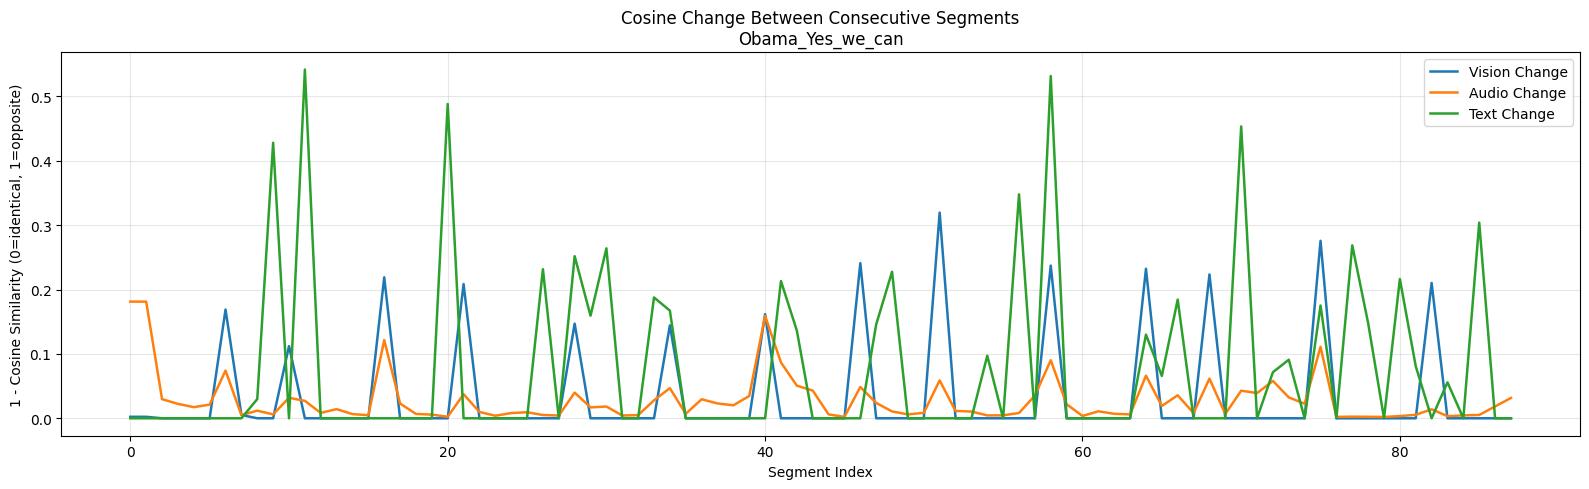

In [3]:
def cosine_change(embeddings):
    scores = []
    for i in range(1, len(embeddings)):
        n = norm(embeddings[i]) * norm(embeddings[i-1])
        if n < 1e-8:
            scores.append(0.0)  # treat zero vectors as identical
        else:
            cos = np.dot(embeddings[i], embeddings[i-1]) / n
            scores.append(1 - cos)
    return np.array([scores[0]] + scores)


v_change = cosine_change(vision)
a_change = cosine_change(audio)
t_change = cosine_change(text)

# Print stats
print("===== Cosine Change Statistics =====")
print(f"\nVision  — Mean: {v_change.mean():.4f}  Std: {v_change.std():.4f}  Max: {v_change.max():.4f}")
print(f"Audio   — Mean: {a_change.mean():.4f}  Std: {a_change.std():.4f}  Max: {a_change.max():.4f}")
print(f"Text    — Mean: {t_change.mean():.4f}  Std: {t_change.std():.4f}  Max: {t_change.max():.4f}")

# Plot
plt.figure(figsize=(16, 5))
plt.plot(v_change, label="Vision Change", linewidth=1.8)
plt.plot(a_change, label="Audio Change", linewidth=1.8)
plt.plot(t_change, label="Text Change", linewidth=1.8)
plt.title(f"Cosine Change Between Consecutive Segments\n{video_name}")
plt.xlabel("Segment Index")
plt.ylabel("1 - Cosine Similarity (0=identical, 1=opposite)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_folder}{video_name}_cosine_change.png", bbox_inches='tight', dpi=300)
plt.show()

For each segment i, it asks: how different is this segment's embedding from the previous one?
The math is simple — cosine similarity between two vectors measures the angle between them:

cos = 1.0 → same direction → identical content → 1 - cos = 0
cos = 0.0 → perpendicular → unrelated content → 1 - cos = 1
cos = -1.0 → opposite → completely different → 1 - cos = 2 (never happens in practice with ImageBind since embeddings are normalized and positive-ish)

The scores[0] padding at the end just gives segment 0 the same value as segment 1 so the array length matches the number of segments.

Reading the Plot
Vision (blue)
Mostly flat near zero with occasional spikes (max 0.32). This tells you:

Flat regions → consecutive segments look visually similar → Obama standing at podium, static shot
Spikes → camera cut or angle change between those two segments
The spikes at segments ~10, ~20, ~57 correspond to the few moments where the video cuts to the crowd or a different camera angle

Audio (orange)
Very smooth, barely leaves zero (max 0.18, mean 0.028). This tells you:

The voice is consistent throughout — same speaker, same microphone, same room
Small bumps around segments 0-3 correspond to the intro before speech starts (different acoustic environment)
The near-zero baseline confirms the audio encoder correctly identifies this as one continuous speech signal

Text (green)
Most dynamic signal, sharp spikes up to 0.54. This tells you:

Large spikes → the transcript content changed significantly between those two segments
Specifically the spikes at ~13, ~15, ~20, ~57, ~80 correspond to Obama's rhetorical structure — he shifts from one argument to another, introduces "Yes We Can", transitions to new topics



OTHER CONCERN:!!!!!!!!!!!!!!!!


 the video is 1m29 sec but because there is  a stride we got 88 segmennt
 HOW WILL WE INTERPRET THIS AND DEAL WITH I????? IDK

Because consecutive segments overlap by 50%, you expect cosine change to naturally be low between neighbors — they literally share half their content. This means:

The spikes you see are even more significant than they look — the content had to change enough to overcome the 1-second overlap and still register a high cosine distance
The flat near-zero regions don't just mean similar content — they mean the overlapping second dominated and the new second brought nothing different
A spike at segment i means the new second entering the window at position i was semantically very different from the second that just left